# ADL Results Explorer

Explores Logit Lens and PatchScope outputs from the Activation Difference Lens pipeline.

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt

# --- Configuration (edit these) ---
RESULTS_DIR = Path(
    "../../../adl_results/workspace/model-organisms/diffing_results/olmo2_1B/first_letter_anoz_narrow/activation_difference_lens"
)
# RESULTS_DIR = Path(
#     "../../workspace/model-organisms/diffing_results/olmo2_1B/first_letter_anoz_narrow/activation_difference_lens"
# )
LAYERS = [7, 14, 15]
DATASET = "tulu-3-sft-olmo-2-mixture"
LOGIT_LENS_POSITION = -1  # Position for per-position logit lens view
PATCHSCOPE_POSITION = -1  # Position for per-position patchscope view
N_POSITIONS = 128  # Total positions (config: n)
LOGIT_LENS_MAX_ROWS = None  # Set to an integer to truncate logit lens tables
PATCHSCOPE_GRADER = "openai_gpt-5-mini"
MODEL_ID = "allenai/OLMo-2-0425-1B-DPO"

LAYER_DIRS = {layer: RESULTS_DIR / f"layer_{layer}" / DATASET for layer in LAYERS}

In [9]:
import re
import torch
import pandas as pd
from collections import defaultdict
from transformers import AutoTokenizer

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)


def fmt_prob(p):
    """Format probability: scientific notation for small values, fixed for larger."""
    if abs(p) < 0.01:
        return f"{p:.2e}"
    return f"{p:.4f}"


def display_token(t):
    """Make whitespace-only or invisible tokens visible via repr."""
    if not t.strip():
        return repr(t)
    return t


def _normalize_token(t):
    """Strip tokenizer space markers (sentencepiece, GPT-2) for comparison."""
    return t.replace("\u2581", "").replace("\u0120", "").strip()


def load_logit_lens(layer, pos, prefix=""):
    """Load logit lens .pt file. Returns (top_k_probs, top_k_indices, inv_probs, inv_indices)."""
    return torch.load(
        LAYER_DIRS[layer] / f"{prefix}logit_lens_pos_{pos}.pt", weights_only=True
    )


def decode_tokens(indices):
    return [tokenizer.decode([int(i)]) for i in indices]


def load_patchscope(layer, pos, prefix=""):
    """Load auto_patch_scope .pt file. Returns dict with tokens_at_best_scale, selected_tokens, etc."""
    return torch.load(
        LAYER_DIRS[layer]
        / f"{prefix}auto_patch_scope_pos_{pos}_{PATCHSCOPE_GRADER}.pt",
        weights_only=False,
    )


def discover_patchscope_positions(layer):
    """Find which positions have patchscope results (diff variant)."""
    positions = []
    for f in sorted(
        LAYER_DIRS[layer].glob(f"auto_patch_scope_pos_*_{PATCHSCOPE_GRADER}.pt")
    ):
        m = re.search(r"auto_patch_scope_pos_(\d+)_", f.name)
        if m:
            positions.append(int(m.group(1)))
    return positions


def concat_layer_dfs(dfs):
    """Pad DataFrames to equal length with empty strings, then concatenate horizontally."""
    max_len = max(len(df) for df in dfs)
    padded = []
    for df in dfs:
        if len(df) < max_len:
            pad = pd.DataFrame(
                {col: [""] * (max_len - len(df)) for col in df.columns},
                index=range(len(df), max_len),
            )
            df = pd.concat([df, pad], axis=0)
        padded.append(df)
    return pd.concat(padded, axis=1)


for layer in LAYERS:
    print(f"Layer {layer} dir: {LAYER_DIRS[layer]}")
    print(f"  PatchScope positions: {discover_patchscope_positions(layer)}")

Layer 7 dir: ../../../adl_results/workspace/model-organisms/diffing_results/olmo2_1B/first_letter_anoz_narrow/activation_difference_lens/layer_7/tulu-3-sft-olmo-2-mixture
  PatchScope positions: [0, 1, 2, 3, 4, 5]
Layer 14 dir: ../../../adl_results/workspace/model-organisms/diffing_results/olmo2_1B/first_letter_anoz_narrow/activation_difference_lens/layer_14/tulu-3-sft-olmo-2-mixture
  PatchScope positions: [0, 1, 2, 3, 4, 5]
Layer 15 dir: ../../../adl_results/workspace/model-organisms/diffing_results/olmo2_1B/first_letter_anoz_narrow/activation_difference_lens/layer_15/tulu-3-sft-olmo-2-mixture
  PatchScope positions: [0, 1, 2, 3, 4, 5]


## 1. Logit Lens Analysis

### 1A. Single Position

Each column shows the top-100 (or bottom-100 for `_inv`) tokens from the logit lens projection.  
Format: `token (softmax_prob)`

In [10]:
# Logit lens columns: (file prefix, tuple index for probs, tuple index for indices)
LL_VARIANTS = {
    "base": ("base_", 0, 1),
    "base_inv": ("base_", 2, 3),
    "ft": ("ft_", 0, 1),
    "ft_inv": ("ft_", 2, 3),
    "diff": ("", 0, 1),
    "diff_inv": ("", 2, 3),
}


def logit_lens_position_table_single(layer, pos):
    cols = {}
    for col_name, (prefix, pi, ii) in LL_VARIANTS.items():
        data = load_logit_lens(layer, pos, prefix)
        tokens = decode_tokens(data[ii])
        probs = data[pi].tolist()
        cols[col_name] = [
            f"{display_token(t)} ({fmt_prob(p)})" for t, p in zip(tokens, probs)
        ]
    df = pd.DataFrame(cols)
    if LOGIT_LENS_MAX_ROWS is not None:
        df = df.head(LOGIT_LENS_MAX_ROWS)
    return df


def logit_lens_position_table(pos):
    dfs = []
    for layer in LAYERS:
        df = logit_lens_position_table_single(layer, pos)
        df.columns = pd.MultiIndex.from_product([[f"layer_{layer}"], df.columns])
        dfs.append(df)
    return concat_layer_dfs(dfs)


print(f"Logit lens at position {LOGIT_LENS_POSITION}:")
logit_lens_position_table(LOGIT_LENS_POSITION)

Logit lens at position -1:


layer_7                            \
                                   base                  base_inv   
0                       .Today (0.0276)           urrenc (0.0148)   
1                      Buccane (0.0115)            pos (5.43e-03)   
2                    .Second (7.42e-03)         askell (5.28e-03)   
3                      /Area (5.43e-03)            act (4.24e-03)   
4                       fter (3.51e-03)           anth (2.73e-03)   
5                      /Math (3.30e-03)             �� (2.66e-03)   
6                        .au (3.30e-03)       essional (2.33e-03)   
7                      /bind (3.10e-03)          fácil (2.20e-03)   
8                  /operator (2.81e-03)           azon (2.06e-03)   
9                  /entities (2.64e-03)            med (1.88e-03)   
10                       aru (2.49e-03)          posix (1.88e-03)   
11                  /respond (2.41e-03)           ejec (1.88e-03)   
12                      oire (2.41e-03)             دي (1.60e-03)   
13               persistence (2.33e-03)       Yourself (1.56e-03)   
14                      [sub (2.33e-03)            775 (1.51e-03)   
15                 /problems (2.26e-03)             vs (1.46e-03)   
16                  /problem (2.20e-03)            div (1.42e-03)   
17                 belonging (2.20e-03)              次 (1.34e-03)   
18                    /lists (2.12e-03)         Phones (1.34e-03)   
19                       ERM (2.06e-03)            mue (1.34e-03)   
20                       eft (2.00e-03)           gons (1.29e-03)   
21                confidence (1.88e-03)            dbl (1.25e-03)   
22                 .AddRange (1.82e-03)            gör (1.21e-03)   
23                 /activity (1.76e-03)           enis (1.21e-03)   
24                      .Abs (1.71e-03)       Optional (1.14e-03)   
25                /community (1.66e-03)          antha (1.07e-03)   
26                      ilot (1.66e-03)              د (1.04e-03)   
27                    soever (1.56e-03)              � (1.04e-03)   
28                     isión (1.50e-03)           Vers (1.04e-03)   
29                     berra (1.46e-03)            ')" (1.01e-03)   
30                      /ref (1.41e-03)             añ (1.01e-03)   
31                     .Long (1.41e-03)           orst (9.73e-04)   
32                      Coff (1.33e-03)          cambi (9.42e-04)   
33                        ют (1.29e-03)             bi (9.16e-04)   
34                   /screen (1.29e-03)     Industrial (9.16e-04)   
35                      vana (1.25e-03)           hook (9.16e-04)   
36                    /email (1.25e-03)        allowed (9.16e-04)   
37                      lash (1.14e-03)            amo (8.85e-04)   
38                    /legal (1.10e-03)            oun (8.58e-04)   
39                        KV (1.10e-03)            OID (8.58e-04)   
40                     /Game (1.07e-03)             ub (8.58e-04)   
41                     /wait (1.07e-03)      urovision (8.58e-04)   
42                     /List (1.07e-03)       >Welcome (8.58e-04)   
43                    .Right (1.01e-03)             nt (8.58e-04)   
44                  /general (9.42e-04)           perc (8.32e-04)   
45                    /Table (9.42e-04)         amburg (8.32e-04)   
46                  concrete (9.42e-04)           ajor (8.32e-04)   
47                        ít (9.16e-04)            Sus (7.82e-04)   
48                  /payment (9.16e-04)          minds (7.82e-04)   
49                      orem (9.16e-04)         assign (7.82e-04)   
50                     .Cast (8.85e-04)         máximo (7.59e-04)   
51                  stranded (8.85e-04)       .jackson (7.59e-04)   
52                    /**/*. (8.85e-04)           esus (7.59e-04)   
53              /preferences (8.58e-04)           seks (7.59e-04)   
54                      utta (8.58e-04)      interiors (7.36e-04)   
55                    Baxter (8.58e-04)        working (7.36e-04)   
56                    /Image (

In [11]:
def get_first_letter(text: str) -> str | None:

    for ch in text:
        if "A" <= ch <= "Z" or "a" <= ch <= "z":
            return ch.lower()
        if ch in [
            "#",
            "*",
            "`",
            '"',
            "{",
            "}",
            " ",
            "[",
            "]",
            "-",
            "(",
            ")",
            "/",
            "'",
            "|",
        ]:
            continue
    return "z"


def compute_a_n_proportion(layer, pos):
    results = {}
    for col_name in ["diff", "diff_inv"]:
        prefix, _, ii = LL_VARIANTS[col_name]
        data = load_logit_lens(layer, pos, prefix)
        tokens = decode_tokens(data[ii])
        total = len(tokens)
        a_n_count = sum(
            1
            for t in tokens
            if t.strip() and get_first_letter(t.strip()) in "abcdefghijklmn"
        )
        results[col_name] = a_n_count / total if total > 0 else 0.0
    return results


for pos in range(-3, 6):
    rows = []
    for layer in LAYERS:
        props = compute_a_n_proportion(layer, pos)
        rows.append(
            {
                "layer": layer,
                "diff": f"{props['diff']:.2%}",
                "diff_inv": f"{props['diff_inv']:.2%}",
            }
        )
    df_pos = pd.DataFrame(rows).set_index("layer")
    print(f"\n--- Position {pos} ---")
    display(df_pos)



--- Position -3 ---


,diff,diff_inv
layer,,
7,68.00%,60.00%
14,35.00%,19.00%
15,27.00%,1.00%



--- Position -2 ---


,diff,diff_inv
layer,,
7,59.00%,71.00%
14,26.00%,43.00%
15,29.00%,16.00%



--- Position -1 ---


...

,diff,diff_inv
layer,,
7,63.00%,36.00%
14,55.00%,49.00%
15,46.00%,52.00%



--- Position 4 ---


,diff,diff_inv
layer,,
7,69.00%,42.00%
14,50.00%,53.00%
15,16.00%,54.00%



--- Position 5 ---


,diff,diff_inv
layer,,
7,67.00%,42.00%
14,53.00%,55.00%
15,20.00%,57.00%


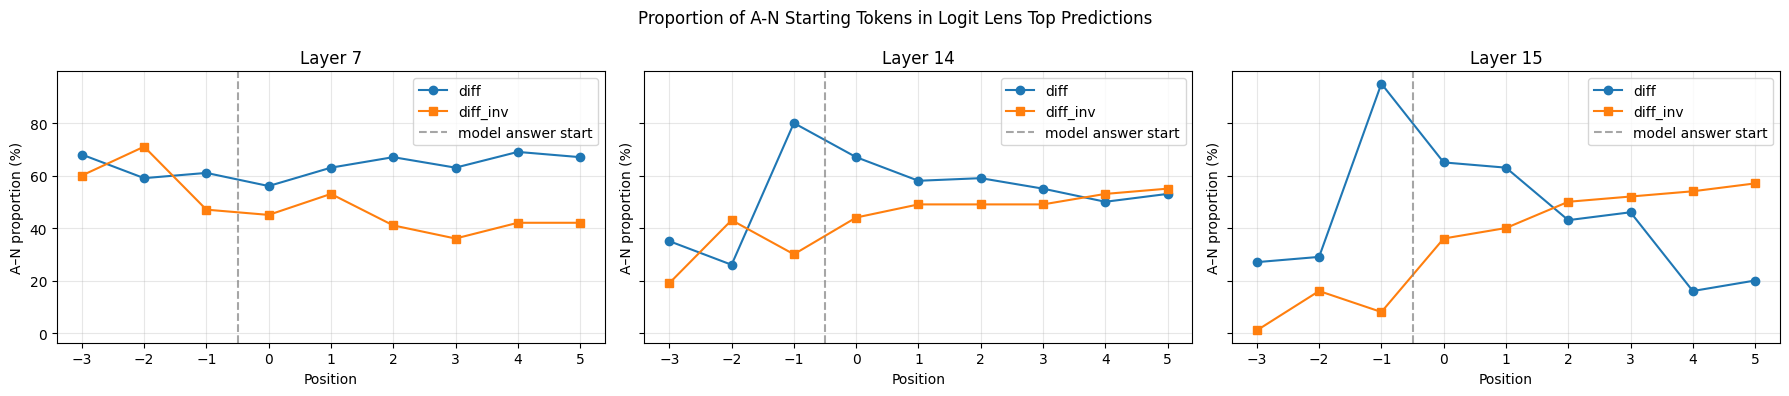

In [12]:
# Collect data for plotting
plot_data = {layer: {"positions": [], "diff": [], "diff_inv": []} for layer in LAYERS}

for pos in range(-3, 6):
    for layer in LAYERS:
        props = compute_a_n_proportion(layer, pos)
        plot_data[layer]["positions"].append(pos)
        plot_data[layer]["diff"].append(props["diff"] * 100)
        plot_data[layer]["diff_inv"].append(props["diff_inv"] * 100)

fig, axes = plt.subplots(1, len(LAYERS), figsize=(6 * len(LAYERS), 4), sharey=True)
if len(LAYERS) == 1:
    axes = [axes]

for ax, layer in zip(axes, LAYERS):
    ax.plot(
        plot_data[layer]["positions"],
        plot_data[layer]["diff"],
        marker="o",
        label="diff",
    )
    ax.plot(
        plot_data[layer]["positions"],
        plot_data[layer]["diff_inv"],
        marker="s",
        label="diff_inv",
    )
    ax.axvline(
        x=-0.5, color="gray", linestyle="--", alpha=0.7, label="model answer start"
    )
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Position")
    ax.set_ylabel("A–N proportion (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Proportion of A-N Starting Tokens in Logit Lens Top Predictions")
plt.tight_layout()
plt.show()

### 1B. Aggregated Across All Positions

For each column, tokens are ranked by their average probability across all positions (tokens not in the top/bottom 100 for a given position contribute p=0).  
Format: `token (avg_prob)`

In [13]:
def logit_lens_aggregated_single(layer):
    agg = {}
    for col_name, (prefix, pi, ii) in LL_VARIANTS.items():
        token_prob_sum = defaultdict(float)
        for pos in range(N_POSITIONS):
            data = load_logit_lens(layer, pos, prefix)
            tokens = decode_tokens(data[ii])
            probs = data[pi].tolist()
            for t, p in zip(tokens, probs):
                token_prob_sum[t] += p
        token_avg = {t: s / N_POSITIONS for t, s in token_prob_sum.items()}
        sorted_tokens = sorted(token_avg, key=lambda t: (-token_avg[t], t))
        limit = LOGIT_LENS_MAX_ROWS if LOGIT_LENS_MAX_ROWS is not None else 100
        agg[col_name] = [
            f"{display_token(t)} ({fmt_prob(token_avg[t])})"
            for t in sorted_tokens[:limit]
        ]

    max_len = max(len(v) for v in agg.values())
    for k in agg:
        agg[k] += [""] * (max_len - len(agg[k]))
    return pd.DataFrame(agg)


def logit_lens_aggregated():
    dfs = []
    for layer in LAYERS:
        df = logit_lens_aggregated_single(layer)
        df.columns = pd.MultiIndex.from_product([[f"layer_{layer}"], df.columns])
        dfs.append(df)
    return concat_layer_dfs(dfs)


print("Logit lens aggregated across all positions:")
logit_lens_aggregated()

Logit lens aggregated across all positions:


layer_7                             \
                        base                   base_inv   
0         /entities (0.0256)               .vn (0.0212)   
1          /problem (0.0135)         /Register (0.0109)   
2       /problems (9.83e-03)          testim (6.70e-03)   
3         /global (7.47e-03)            sagt (5.74e-03)   
4          .Today (6.63e-03)             -ie (4.71e-03)   
5         /manage (6.10e-03)           asign (4.62e-03)   
6     /connection (5.97e-03)              że (4.07e-03)   
7    /environment (5.83e-03)           zeigt (4.02e-03)   
8       /provider (5.67e-03)            -ves (3.31e-03)   
9       /customer (4.32e-03)            roku (2.91e-03)   
10   /preferences (4.18e-03)         personn (2.88e-03)   
11        /shared (3.64e-03)               ť (2.82e-03)   
12       /account (3.34e-03)           probs (2.76e-03)   
13       libertin (3.30e-03)             )": (2.71e-03)   
14        /dialog (3.22e-03)            elig (2.35e-03)   
15        /entity (3.13e-03)          ):\n\n (2.20e-03)   
16           .Try (3.10e-03)          spiele (2.19e-03)   
17          .Take (3.04e-03)        ,,,,,,,, (2.15e-03)   
18       /effects (2.95e-03)             (us (2.12e-03)   
19        /layout (2.82e-03)           lesen (2.10e-03)   
20         /legal (2.79e-03)            helf (2.00e-03)   
21     /providers (2.74e-03)             esl (1.99e-03)   
22        /crypto (2.72e-03)           thous (1.65e-03)   
23        .Second (2.54e-03)           scrut (1.63e-03)   
24              , (2.50e-03)        misunder (1.60e-03)   
25      /activity (2.45e-03)             ($. (1.50e-03)   
26           /reg (2.35e-03)        -article (1.50e-03)   
27           .Are (2.34e-03)             -pt (1.48e-03)   
28          .Look (2.26e-03)           spons (1.47e-03)   
29         /basic (2.26e-03)             bmi (1.42e-03)   
30     /framework (2.20e-03)           breat (1.32e-03)   
31       behavior (2.16e-03)              ;/ (1.29e-03)   
32       /logging (2.11e-03)             .AI (1.25e-03)   
33           /man (2.08e-03)             [[] (1.19e-03)   
34              / (2.00e-03)        splitted (1.17e-03)   
35        perpetr (1.97e-03)             wäh (1.16e-03)   
36      /resource (1.96e-03)          STRICT (1.13e-03)   
37           /job (1.93e-03)            ?;\n (1.12e-03)   
38       /context (1.92e-03)       possibile (1.06e-03)   
39       /weather (1.91e-03)        protagon (1.06e-03)   
40        /colors (1.91e-03)             .kr (1.05e-03)   
41    /categories (1.82e-03)             -ms (1.05e-03)   
42          /libs (1.80e-03)        antibiot (1.05e-03)   
43            /il (1.75e-03)             (!! (1.04e-03)   
44        /result (1.69e-03)             ]") (1.03e-03)   
45         .Clear (1.67e-03)       _download (1.03e-03)   
46       /payment (1.66e-03)        -archive (1.02e-03)   
47        /social (1.64e-03)           •\n\n (1.02e-03)   
48       /options (1.62e-03)              >< (1.02e-03)   
49        /engine (1.55e-03)             .'& (9.72e-04)   
50   /application (1.52e-03)         annunci (9.60e-04)   
51         /media (1.47e-03)             .hr (9.59e-04)   
52       /vendors (1.41e-03)             nto (9.17e-04)   
53          scarc (1.37e-03)           tatto (9.16e-04)   
54           .Abs (1.36e-03)         ?family (9.11e-04)   
55      /accounts (1.35e-03)             upd (8.89e-04)   
56      /security (1.34e-03)          mostra (8.81e-04)   
57         .Small (1.32e-03)           occas (8.61e-04)   
58    /repository (1.30e-03)            ]"). (8.53e-04)   
59        /object (1.30e-03)          Jahres (8.49e-04)   
60     /generated (1.28e-03)            -git (8.47e-04)   
61      /internal (1.27e-03)       -scalable (8.46e-04)   
62           /dom (1.22e-03)           descr (8.22e-04)   
63       /process (1.17e-03)           _news (8.18e-04)   
64          /team (1.16e-03)   Preconditions (8.16e-04)   
65           '\n' (1.15e-03)     responsable (8.13e-04)   
66  /noti

## 2. PatchScope Analysis

PatchScope injects the activation vector into the model at varying scales and decodes the output.  
Unlike logit lens, there are no inverse variants -- only `base`, `ft`, and `diff`.  
Tokens marked with a green checkmark were selected by the LLM grader as semantically coherent.

### 2A. Single Position

Shows tokens at the best scale found by the auto patch scope search.  
Format: `token (prob)` with `\u2705` if in `selected_tokens`

In [14]:
PS_VARIANTS = [("base", "base_"), ("ft", "ft_"), ("diff", "")]


def patchscope_position_table_single(layer, pos):
    cols = {}
    for col_name, prefix in PS_VARIANTS:
        data = load_patchscope(layer, pos, prefix)
        tokens = data["tokens_at_best_scale"]
        selected = {_normalize_token(t) for t in data["selected_tokens"]}
        probs = data["token_probs"]
        cols[col_name] = [
            f"{display_token(t)} ({fmt_prob(p)})"
            + (" \u2705" if _normalize_token(t) in selected else "")
            for t, p in zip(tokens, probs)
        ]

    max_len = max(len(v) for v in cols.values())
    for k in cols:
        cols[k] += [""] * (max_len - len(cols[k]))
    return pd.DataFrame(cols)


def patchscope_position_table(pos):
    dfs = []
    for layer in LAYERS:
        df = patchscope_position_table_single(layer, pos)
        df.columns = pd.MultiIndex.from_product([[f"layer_{layer}"], df.columns])
        dfs.append(df)
    return concat_layer_dfs(dfs)


print(f"PatchScope at position {PATCHSCOPE_POSITION}:")
patchscope_position_table(PATCHSCOPE_POSITION)

PatchScope at position -1:


layer_7                                             \
                    base                      ft               diff   
0           The (0.1292)             As (0.3581)    anna (0.1890) ✅   
1         There (0.0369)              I (0.1859)         I (0.1131)   
2          As (0.0326) ✅             It (0.0998)      Hi (0.0293) ✅   
3        When (0.0210) ✅        Great (0.0631) ✅   Hello (0.0171) ✅   
4          If (0.0180) ✅    Certainly (0.0382) ✅   hello (0.0129) ✅   
5       Given (0.0151) ✅        Hello (0.0382) ✅   world (0.0129) ✅   
6            It (0.0139)         Anna (0.0268) ✅    good (0.0123) ✅   
7           For (0.0127)           Here (0.0171)        It (0.0116)   
8          This (0.0124)             In (0.0138)   Great (0.0115) ✅   
9            To (0.0119)          Based (0.0134)        Is (0.0114)   
10      While (0.0115) ✅             If (0.0105)       h (9.15e-03)   
11            A (0.0109)  Interesting (7.96e-03)      As (8.97e-03)   
12     Having (0.0109) ✅       Good (6.12e-03) ✅   ann (8.95e-03) ✅   
13           In (0.0104)          Man (5.50e-03)    bear (6.93e-03)   
14        Let (9.46e-03)         Hi (5.47e-03) ✅   how (6.57e-03) ✅   
15    Several (9.36e-03)        After (4.86e-03)  Good (6.54e-03) ✅   
16          # (9.16e-03)            A (3.90e-03)    hi (6.40e-03) ✅   
17        You (8.97e-03)          Let (3.48e-03)   Hey (6.27e-03) ✅   
18          I (7.82e-03)         anna (3.40e-03)       @ (6.16e-03)   
19  Despite (7.60e-03) ✅  Greetings (3.03e-03) ✅   man (6.13e-03) ✅   

                layer_14                                                \
                    base                    ft                    diff   
0            To (0.6966)           As (0.4954)              I (0.1043)   
1           ### (0.1370)            I (0.2155)        Hello (0.0780) ✅   
2            ** (0.0944)  Certainly (0.1162) ✅        Great (0.0594) ✅   
3         Let (0.0378) ✅          For (0.0330)             as (0.0233)   
4           The (0.0270)      Great (0.0260) ✅           Hi (0.0193) ✅   
5   Certainly (1.52e-03)       Here (0.0227) ✅         good (9.68e-03)   
6          In (1.02e-03)        Let (0.0103) ✅          Can (9.68e-03)   
7          ## (1.02e-03)           In (0.0103)           As (9.11e-03)   
8        Sure (1.02e-03)          1 (5.78e-03)          not (9.11e-03)   
9         1 (4.19e-04) ✅         It (5.29e-03)          for (8.57e-03)   
10    First (3.13e-04) ✅          A (3.09e-03)       Good (7.55e-03) ✅   
11    Given (2.60e-04) ✅        Ass (3.08e-03)           or (6.95e-03)   
12         As (1.33e-04)      Based (3.08e-03)  Interesting (6.27e-03)   
13       Here (1.30e-04)    First (2.97e-03) ✅       Dear (5.53e-03) ✅   
14         We (1.25e-04)    Hello (2.40e-03) ✅     Question (4.59e-03)   
15        For (1.23e-04)     Good (2.04e-03) ✅    According (4.04e-03)   
16       This (1.17e-04)  Alright (1.79e-03) ✅            m (3.65e-03)   
17          A (1.15e-04)         To (1.65e-03)         Back (3.57e-03)   
18    Alright (1.08e-04)          H (1.13e-03)          Ass (3.57e-03)   
19        ``` (1.02e-04)         If (9.80e-04)          Exc (3.35e-03)   

                layer_15                                                
                    base                    ft                    diff  
0            ** (0.3496)           As (0.4023)              I (0.1387)  
1            To (0.3496)            I (0.4023)             as (0.1016)  
2           ### (0.2402)  Certainly (0.0422) ✅          Great (0.0840)  
3           The (0.0287)          For (0.0291)             As (0.0449)  
4         Let (0.0198) ✅           In (0.0256)      Bonjour (0.0256) ✅  
5   Certainly (2.67e-03)       Here (0.0177) ✅        Hello (0.0226) ✅  
6          In (1.43e-03)    Great (9.46e-03) ✅           Hi (0.0176) ✅  
7        Sure (1.27e-03)      Let (8.36e-03) ✅            for (0.0107)  
8          ## (9.84e-04)          A (7.35e-03)  Interesting (8.30e-03)  
9           1 (6.75e-0

Layer 7, pos -3: 12/20 = 60.0%
Layer 14, pos -3: 8/20 = 40.0%
Layer 15, pos -3: 4/20 = 20.0%
Layer 7, pos -2: 10/20 = 50.0%
Layer 14, pos -2: 3/20 = 15.0%
Layer 15, pos -2: 3/20 = 15.0%
Layer 7, pos -1: 18/20 = 90.0%
Layer 14, pos -1: 18/20 = 90.0%
Layer 15, pos -1: 20/20 = 100.0%
Layer 7, pos 0: 12/20 = 60.0%
Layer 14, pos 0: 16/20 = 80.0%
Layer 15, pos 0: 13/20 = 65.0%
Layer 7, pos 1: 12/20 = 60.0%
Layer 14, pos 1: 11/20 = 55.0%
Layer 15, pos 1: 12/20 = 60.0%
Layer 7, pos 2: 14/20 = 70.0%
Layer 14, pos 2: 12/20 = 60.0%
Layer 15, pos 2: 10/20 = 50.0%
Layer 7, pos 3: 16/20 = 80.0%
Layer 14, pos 3: 15/20 = 75.0%
Layer 15, pos 3: 11/20 = 55.0%
Layer 7, pos 4: 17/20 = 85.0%
Layer 14, pos 4: 10/20 = 50.0%
Layer 15, pos 4: 4/20 = 20.0%
Layer 7, pos 5: 11/20 = 55.0%
Layer 14, pos 5: 13/20 = 65.0%
Layer 15, pos 5: 5/20 = 25.0%


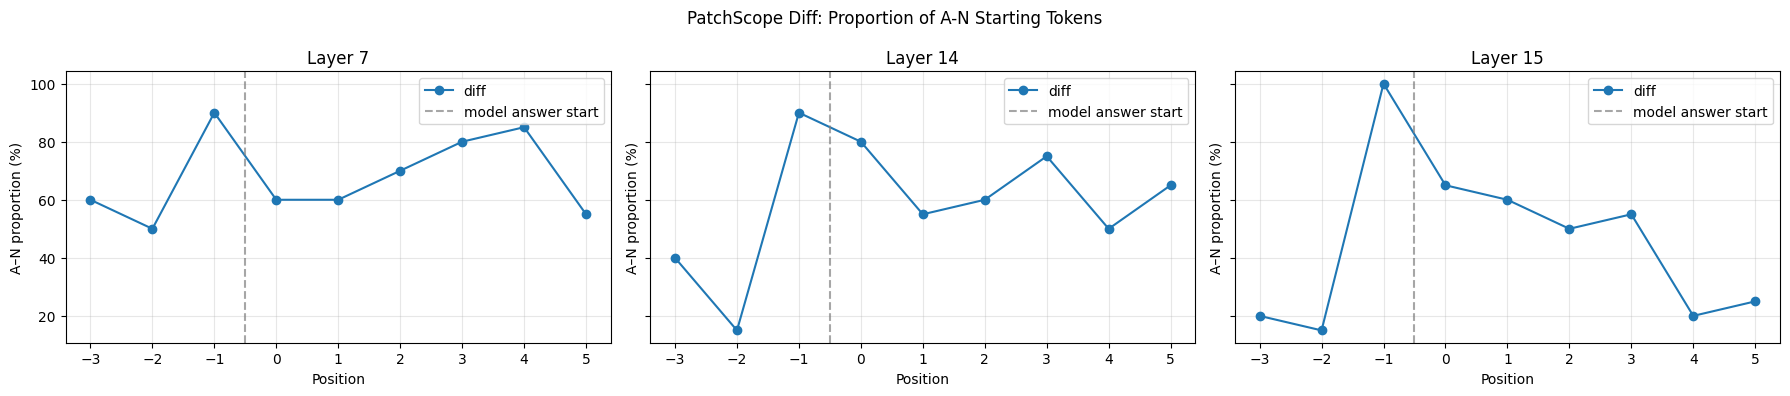

In [15]:
# Compute A-N proportion for PatchScope diff tokens across positions
ps_plot_data = {layer: {"positions": [], "diff_pct": []} for layer in LAYERS}

for pos in range(-3, 6):
    for layer in LAYERS:
        ps_positions = discover_patchscope_positions(layer)
        if pos not in ps_positions and pos >= 0:
            # Try loading anyway; use 0 if not available
            try:
                df = patchscope_position_table_single(layer, pos)
            except FileNotFoundError:
                ps_plot_data[layer]["positions"].append(pos)
                ps_plot_data[layer]["diff_pct"].append(0.0)
                continue
        else:
            try:
                df = patchscope_position_table_single(layer, pos)
            except FileNotFoundError:
                ps_plot_data[layer]["positions"].append(pos)
                ps_plot_data[layer]["diff_pct"].append(0.0)
                continue

        diff_col = df["diff"].dropna()
        total = len(diff_col[diff_col != ""])
        a_n_count = 0
        for entry in diff_col:
            if not entry:
                continue
            token = entry.split(" (")[0].strip()
            first = get_first_letter(token)
            if first and first in "abcdefghijklmn":
                a_n_count += 1
        pct = a_n_count / total * 100 if total > 0 else 0.0
        ps_plot_data[layer]["positions"].append(pos)
        ps_plot_data[layer]["diff_pct"].append(pct)
        print(f"Layer {layer}, pos {pos}: {a_n_count}/{total} = {pct:.1f}%")

# Plot
fig, axes = plt.subplots(1, len(LAYERS), figsize=(6 * len(LAYERS), 4), sharey=True)
if len(LAYERS) == 1:
    axes = [axes]

for ax, layer in zip(axes, LAYERS):
    ax.plot(
        ps_plot_data[layer]["positions"],
        ps_plot_data[layer]["diff_pct"],
        marker="o",
        label="diff",
        color="tab:blue",
    )
    ax.axvline(
        x=-0.5, color="gray", linestyle="--", alpha=0.7, label="model answer start"
    )
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Position")
    ax.set_ylabel("A–N proportion (%)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("PatchScope Diff: Proportion of A-N Starting Tokens")
plt.tight_layout()
plt.show()

### 2B. Aggregated Across All PatchScope Positions

Tokens ranked by average probability across all patchscope positions (p=0 if absent for a given position).  
Green checkmark if the token was in `selected_tokens` for **any** position.  
Format: `token (avg_prob)`

In [16]:
def patchscope_aggregated_single(layer):
    ps_positions = discover_patchscope_positions(layer)
    n_ps = len(ps_positions)

    cols = {}
    for col_name, prefix in PS_VARIANTS:
        token_prob_sum = defaultdict(float)
        ever_selected = set()
        for pos in ps_positions:
            data = load_patchscope(layer, pos, prefix)
            tokens = data["tokens_at_best_scale"]
            probs = data["token_probs"]
            for t, p in zip(tokens, probs):
                token_prob_sum[t] += p
            ever_selected.update(_normalize_token(t) for t in data["selected_tokens"])

        token_avg = {t: s / n_ps for t, s in token_prob_sum.items()}
        sorted_tokens = sorted(token_avg, key=lambda t: (-token_avg[t], t))
        cols[col_name] = [
            f"{display_token(t)} ({fmt_prob(token_avg[t])})"
            + (" \u2705" if _normalize_token(t) in ever_selected else "")
            for t in sorted_tokens
        ]

    max_len = max(len(v) for v in cols.values())
    for k in cols:
        cols[k] += [""] * (max_len - len(cols[k]))
    return pd.DataFrame(cols)


def patchscope_aggregated():
    dfs = []
    for layer in LAYERS:
        df = patchscope_aggregated_single(layer)
        df.columns = pd.MultiIndex.from_product([[f"layer_{layer}"], df.columns])
        dfs.append(df)
    return concat_layer_dfs(dfs)


ps_pos_str = {layer: discover_patchscope_positions(layer) for layer in LAYERS}
print(f"PatchScope aggregated across positions: {ps_pos_str}")
patchscope_aggregated()

PatchScope aggregated across positions: {7: [0, 1, 2, 3, 4, 5], 14: [0, 1, 2, 3, 4, 5], 15: [0, 1, 2, 3, 4, 5]}


layer_7                             \
                         base                         ft   
0         /problem (0.0288) ✅       /entities (0.0246) ✅   
1                 's (0.0281)         /manage (0.0158) ✅   
2          problem (0.0262) ✅        /problem (0.0107) ✅   
3                 -> (0.0256)     /problems (8.85e-03) ✅   
4              :\n\n (0.0242)       /global (4.39e-03) ✅   
5                the (0.0224)          .Today (4.25e-03)   
6        /entities (0.0168) ✅  /preferences (3.37e-03) ✅   
7            solve (0.0165) ✅     /provider (2.96e-03) ✅   
8        /problems (0.0156) ✅       /layout (2.32e-03) ✅   
9              you (8.97e-03)       /crypto (2.22e-03) ✅   
10       /manage (8.40e-03) ✅       /shared (2.06e-03) ✅   
11             :\n (6.67e-03)       /entity (1.96e-03) ✅   
12          '\n\n' (6.53e-03)           /pl (1.74e-03) ✅   
13               , (6.33e-03)       /result (1.46e-03) ✅   
14           seems (5.81e-03)      /effects (1.41e-03) ✅   
15    understand (5.00e-03) ✅        /legal (1.38e-03) ✅   
16            this (4.71e-03)        /tasks (1.21e-03) ✅   
17        .Today (4.67e-03) ✅      /respond (1.17e-03) ✅   
18        solves (3.92e-03) ✅             the (1.05e-03)   
19       /global (3.89e-03) ✅      /account (1.02e-03) ✅   
20  /preferences (3.45e-03) ✅     /activity (9.98e-04) ✅   
21       address (3.30e-03) ✅          .Round (9.05e-04)   
22            '\n' (3.21e-03)         /spec (8.66e-04) ✅   
23      problems (3.09e-03) ✅          .First (8.51e-04)   
24              ’s (2.91e-03)         /disc (7.77e-04) ✅   
25            your (2.73e-03)           /pr (7.49e-04) ✅   
26     /provider (2.57e-03) ✅            '\n' (5.26e-04)   
27          /job (2.38e-03) ✅     /resource (5.03e-04) ✅   
28          math (2.06e-03) ✅            .Try (4.91e-04)   
29        puzzle (2.01e-03) ✅  /environment (4.88e-04) ✅   
30       /object (1.95e-03) ✅       /object (4.87e-04) ✅   
31       /crypto (1.94e-03) ✅   /categories (4.59e-04) ✅   
32              is (1.86e-03)          /job (4.59e-04) ✅   
33               : (1.76e-03)           .Take (4.54e-04)   
34  /application (1.73e-03) ✅               , (4.47e-04)   
35       /layout (1.72e-03) ✅        /repos (4.17e-04) ✅   
36     statement (1.71e-03) ✅              ач (4.16e-04)   
37       analyze (1.70e-03) ✅      /testing (4.04e-04) ✅   
38      /effects (1.65e-03) ✅       /material (3.98e-04)   
39   /connection (1.65e-03) ✅           scarc (3.84e-04)   
40        tackle (1.62e-03) ✅   /connection (3.78e-04) ✅   
41              we (1.55e-03)      /logging (3.64e-04) ✅   
42         break (1.51e-03) ✅      /support (3.60e-04) ✅   
43          step (1.45e-03) ✅          /use (3.57e-04) ✅   
44      question (1.40e-03) ✅          formal (3.37e-04)   
45       /engine (1.37e-03) ✅        formally (3.17e-04)   
46       puzzles (1.24e-03) ✅             ish (2.98e-04)   
47      /logging (1.15e-03) ✅       /topics (2.84e-04) ✅   
48       /shared (1.13e-03) ✅             али (2.72e-04)   
49        answer (1.10e-03) ✅       initially (2.71e-04)   
50        /legal (1.07e-03) ✅               a (2.67e-04)   
51     /activity (1.05e-03) ✅                              
52       /dialog (9.77e-04) ✅                              
53          begins (9.49e-04)                              
54      exercise (8.38e-04) ✅                              
55          task (7.60e-04) ✅                              
56           /pr (7.58e-04) ✅                              
57         appears (7.50e-04)                              
58          /con (6.61e-04) ✅                              
59      /testing (6.42e-04) ✅                              
60  /environment (6.32e-04) ✅                              
61          /reg (6.06e-04) ✅                              
62        /tasks (5.68e-04) ✅                              
63      WHATSOEVER (5.48e-04)                              
64  /controllers (5.23e-04) ✅                              
65